# Imports

In [1]:
from pathlib import Path
import shutil

import ccdproc
import astropy.io.fits as fits

import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import astroalign as aa
import math
from astropy.io.fits import Header
import sep

# Check Environment

Check if science and flat directories exist and are populated:

In [2]:
directory_names = ["science", "flats"]
project_root = Path.cwd()

for directory_name in directory_names:
    target_dir = project_root / "data" / directory_name
    if not target_dir.exists() or not target_dir.is_dir():
        raise RuntimeError(f"Directory {target_dir} does not exist")
    if not any(target_dir.iterdir()):
        raise RuntimeError(f"Directory {target_dir} contains no files")

Generate and clean necessary directories:

In [3]:
directory_names = ["flat-fielded", "aligned", "combined", "masters"]
project_root = Path.cwd()

for directory_name in directory_names:
    target_dir = project_root / "generated" / directory_name
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True)

# Helpers

In [4]:
def get_v_min_max(*fits_data):
    return min(np.percentile(data.data - data.mean(), 5) for data in fits_data), max(
        np.percentile(data.data - data.mean(), 95) for data in fits_data)

In [5]:
def plot_fits(fits_data, titles, cbar_label):
    n = len(fits_data)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), constrained_layout=True)

    if n == 1:
        axes = [axes]

    processed = [fd - fd.mean() for fd in fits_data]
    vmin, vmax = get_v_min_max(*processed)

    for ax, data, title in zip(axes, processed, titles):
        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap='magma')
        ax.set_title(title)

    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.04, pad=0.02)
    cbar.set_label(cbar_label)
    # plt.show()

# Combine flats

Combine helper function:

In [6]:
def combine_flats(filenames, save_name):
    images = []
    for f in filenames:
        hdr = fits.getheader(f)
        data = fits.getdata(f) + 1.0 * hdr['PEDESTAL']
        data /= data.mean()
        images.append(ccdproc.CCDData(data, unit=u.adu))

    flat = ccdproc.combine(images, method='average')
    fits.writeto(f'./generated/masters/{save_name}.fits', flat.data, overwrite=True)
    return flat.data

Combine V and r flats:

In [7]:
flat_V = combine_flats(filenames=['./data/flats/flat%dV.FIT' % j for j in range(1, 11)], save_name="masterFlatV")
flat_r = combine_flats(filenames=['./data/flats/flat%dr.FIT' % j for j in range(1, 11)], save_name="masterFlatr")

Assert correct normalisation:

In [8]:
assert flat_V.mean() == 1.0, "V master flat is not normalised!"
assert flat_r.mean() == 1.0, "r master flat is not normalised!"

Plot results:

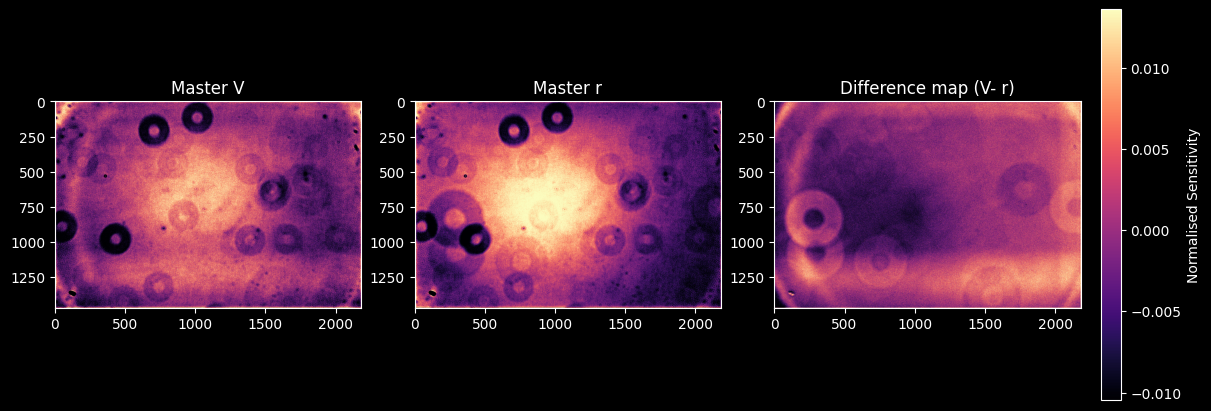

In [9]:
plot_fits([flat_V, flat_r, flat_V - flat_r], ["Master V", "Master r", "Difference map (V- r)"], "Normalised Sensitivity")

Sensitivity variation analysis:

In [10]:
print("Sensitivity variation analysis:")
print(f"FlatV max: {np.max(flat_V.data) - np.min(flat_V.data)} | std dev: {np.std(flat_V.data)} ")
print(f"Flatr max: {np.max(flat_r.data) - np.min(flat_r.data)} | std dev: {np.std(flat_r.data)} ")

Sensitivity variation analysis:
FlatV max: 0.4901246409743598 | std dev: 0.0071324725432577105 
Flatr max: 0.35615248635490504 | std dev: 0.009080286588052837 


# Make Flat Fielded

Make helper function:

In [11]:
def make_flat_fielded(suffix, master_flat):
    for j in range(1, 11):
        file_in = f"./data/science/science{j}{suffix}.FIT"
        file_out = f"./generated/flat-fielded/science{j}{suffix}f.fits"
        print("Processing file: %s -> %s" % (file_in, file_out))

        hdr = fits.getheader(file_in)
        data = fits.getdata(file_in) + 1.0 * hdr['PEDESTAL']

        data /= master_flat

        hdr.add_comment("Pedestal corrected")
        hdr.add_comment("Flat-fielded with master_flat")
        hdr.add_comment("Saved as 32-bit integer")

        fits.writeto(file_out, np.int32(data), hdr, overwrite=True)

Make flat fielded:

In [12]:
make_flat_fielded("V", fits.getdata("./generated/masters/masterFlatV.fits"))
make_flat_fielded("r", fits.getdata("./generated/masters/masterFlatr.fits"))


Processing file: ./data/science/science1V.FIT -> ./generated/flat-fielded/science1Vf.fits
Processing file: ./data/science/science2V.FIT -> ./generated/flat-fielded/science2Vf.fits
Processing file: ./data/science/science3V.FIT -> ./generated/flat-fielded/science3Vf.fits
Processing file: ./data/science/science4V.FIT -> ./generated/flat-fielded/science4Vf.fits
Processing file: ./data/science/science5V.FIT -> ./generated/flat-fielded/science5Vf.fits
Processing file: ./data/science/science6V.FIT -> ./generated/flat-fielded/science6Vf.fits
Processing file: ./data/science/science7V.FIT -> ./generated/flat-fielded/science7Vf.fits
Processing file: ./data/science/science8V.FIT -> ./generated/flat-fielded/science8Vf.fits
Processing file: ./data/science/science9V.FIT -> ./generated/flat-fielded/science9Vf.fits
Processing file: ./data/science/science10V.FIT -> ./generated/flat-fielded/science10Vf.fits
Processing file: ./data/science/science1r.FIT -> ./generated/flat-fielded/science1rf.fits
Processi

Plot results:

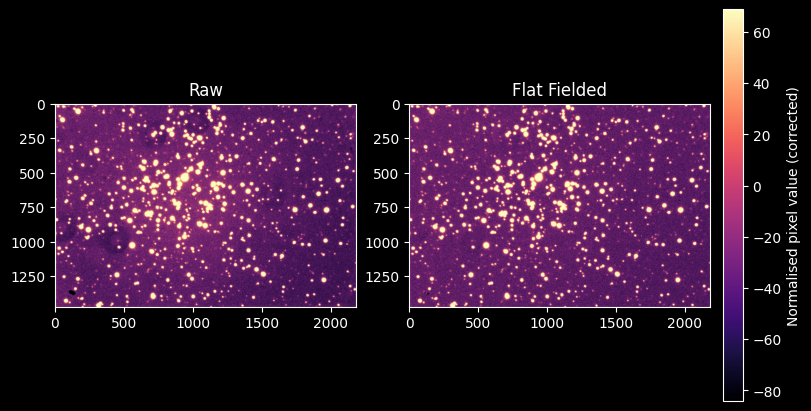

In [13]:
INDEX = 3
raw = fits.getdata(f"./data/science/science{INDEX}r.FIT")
flat_fielded = fits.getdata(f"./generated/flat-fielded/science{INDEX}rf.fits")
plot_fits([raw, flat_fielded], ["Raw", "Flat Fielded"], "Normalised pixel value (corrected)")

# Align

Define helper function:

In [14]:

# Read target image
def align(suffix, datatarg):
    fits.writeto(f"./generated/aligned/science1{suffix}t.fits", datatarg, overwrite=True)

    for j in range(2, 11):
        file_in = f"./generated/flat-fielded/science{j}{suffix}.fits"
        file_out = f"./generated/aligned/science{j}{suffix}t.fits"

        datasrc = fits.getdata(file_in)

        T, (source_pos_array, target_pos_array) = aa.find_transform(datasrc, datatarg)
        print(f"Image name = {file_in}  shifts= {T.translation} rot= {T.rotation * 180 / math.pi}  scale = {T.scale}")

        assert abs(T.rotation * 180 / math.pi) < 0.01, "Rotation deviates too much!"
        assert abs(T.scale - 1) < 0.0002, "Scale deviates too much!"

        data_tran, footprint = aa.apply_transform(T, datasrc, datatarg)
        fits.writeto(file_out, data_tran, overwrite=True)


Align images:

In [15]:
datatarg = fits.getdata(f'./generated/flat-fielded/science1Vf.fits')
align("Vf", datatarg)
align("rf", datatarg)

Image name = ./generated/flat-fielded/science2Vf.fits  shifts= [-0.6177937   1.65201819] rot= -0.0012524002308583503  scale = 1.000078656417958
Image name = ./generated/flat-fielded/science3Vf.fits  shifts= [-2.12211109  2.10279622] rot= 0.0015954975785294867  scale = 0.9999849730161242
Image name = ./generated/flat-fielded/science4Vf.fits  shifts= [-2.61447818  3.07290393] rot= -0.00046059895705181394  scale = 0.9999922606565693
Image name = ./generated/flat-fielded/science5Vf.fits  shifts= [-2.7413116   3.57883064] rot= -0.0016040846527379372  scale = 1.000023970611019
Image name = ./generated/flat-fielded/science6Vf.fits  shifts= [-3.29105507  4.28391811] rot= -0.001260662524501236  scale = 0.9999825927178166
Image name = ./generated/flat-fielded/science7Vf.fits  shifts= [-3.77500249  4.2204149 ] rot= -0.0010740807404597678  scale = 0.9999958875307577
Image name = ./generated/flat-fielded/science8Vf.fits  shifts= [-4.20368585  5.05399074] rot= -0.0012171937307103474  scale = 0.99999

# Combine

Helper function for combining:

In [16]:
def combine_aligned(suffix):
    filenames = [f"./generated/aligned/science{j}{suffix}ft.fits" for j in range(1, 11)]
    images = [ccdproc.CCDData(fits.getdata(f), unit=u.adu) for f in filenames]
    sciAvg = ccdproc.combine(images, method='average')

    header = Header(sciAvg.meta)

    # Save the output
    fits.writeto(f'./generated/combined/{suffix}cmb.fits', sciAvg.data, header, overwrite=True)


Combine:

In [17]:
combine_aligned("V")
combine_aligned("r")

Plot results:

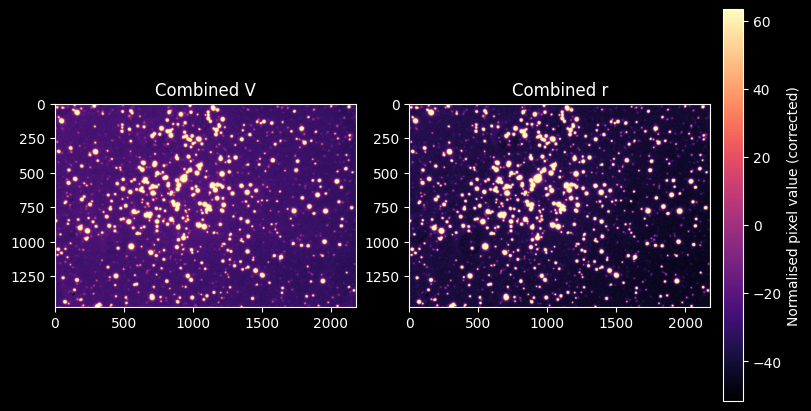

In [18]:
combinedV = fits.getdata(f"./generated/combined/Vcmb.fits")
combinedr = fits.getdata(f"./generated/combined/rcmb.fits")
plot_fits([combinedV, combinedr], ["Combined V", "Combined r"], "Normalised pixel value (corrected)")

# Extract Background

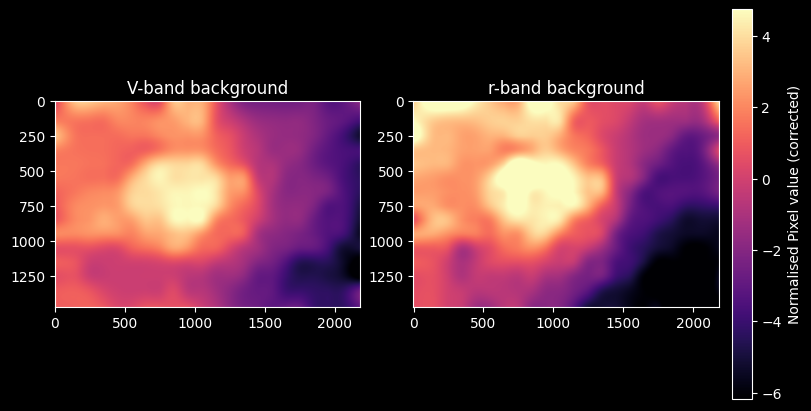

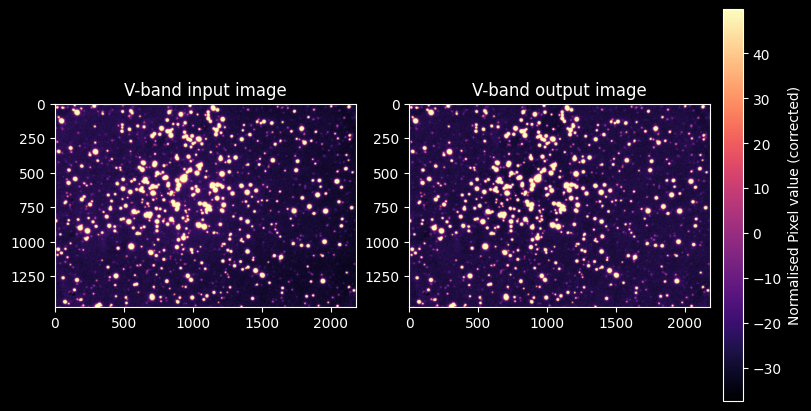

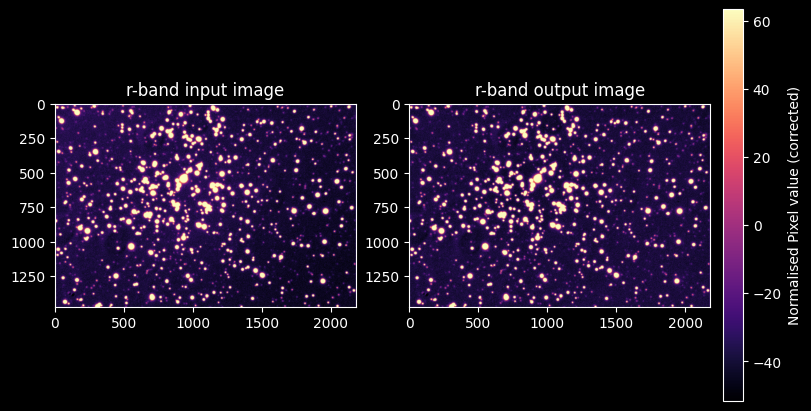

In [19]:
# Load the images
Vdat = fits.getdata('./generated/combined/Vcmb.fits') # !!!!!!!Need to add wcs
rdat = fits.getdata('./generated/combined/rcmb.fits') # !!!!!!!Need to add wcs

# # Swap around the byte order (RAISES!!!!)
# srdat = rdat.byteswap().newbyteorder()
# sVdat = Vdat.byteswap().newbyteorder()

srdat = np.array(rdat, dtype=np.float32)
sVdat = np.array(Vdat, dtype=np.float32)

# Define the background model
bw, bh = 100, 100  # Sizes of background boxes
fw, fh = 3, 3  # Number of background boxes
rbkg = sep.Background(srdat, bw=bw, bh=bh, fw=fw, fh=fh)
Vbkg = sep.Background(sVdat, bw=bw, bh=bh, fw=fw, fh=fh)

# Subtract the background
r_data_sub = srdat - rbkg.back()
V_data_sub = sVdat - Vbkg.back()

plot_fits([Vbkg.back(), rbkg.back()], ["V-band background", "r-band background"], "Normalised Pixel value (corrected)")
plot_fits([sVdat, V_data_sub], ["V-band input image", "V-band output image"], "Normalised Pixel value (corrected)")
plot_fits([srdat, r_data_sub], ["r-band input image", "r-band output image"], "Normalised Pixel value (corrected)")


# Extract Sources

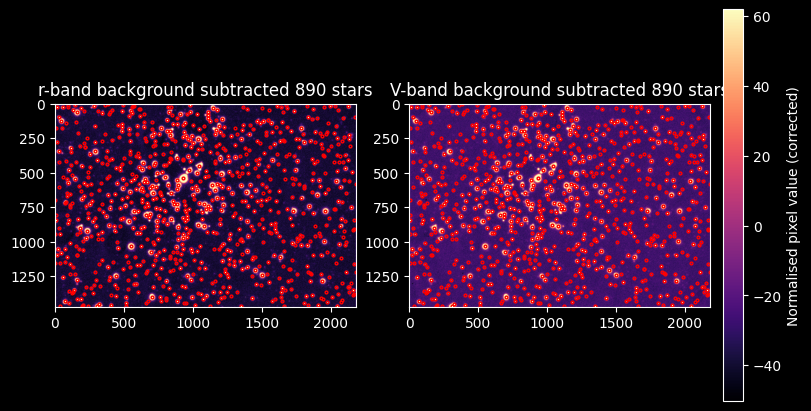

In [20]:
# Now extract the sources from the background-subtracted V-band image
objects = sep.extract(V_data_sub, 1.5, minarea=5, err=Vbkg.globalrms)

plot_fits([r_data_sub, V_data_sub], [f"r-band background subtracted {len(objects)} stars", f"V-band background subtracted {len(objects)} stars"], "Normalised pixel value (corrected)")

plt.subplot(1, 2, 1)
plt.plot(objects['x'], objects['y'], 'ro', markersize=2, markerfacecolor='None')

plt.subplot(1, 2, 2)
plt.plot(objects['x'], objects['y'], 'ro', markersize=2, markerfacecolor='None')

plt.show()


In [21]:
aper = 3.0
print('Aperture radius = %0.2f' % aper)
print('Based on a measured FWHM of %0.2f pixels' % 1)

Aperture radius = 3.00
Based on a measured FWHM of 1.00 pixels


# Magnitude Error Analysis

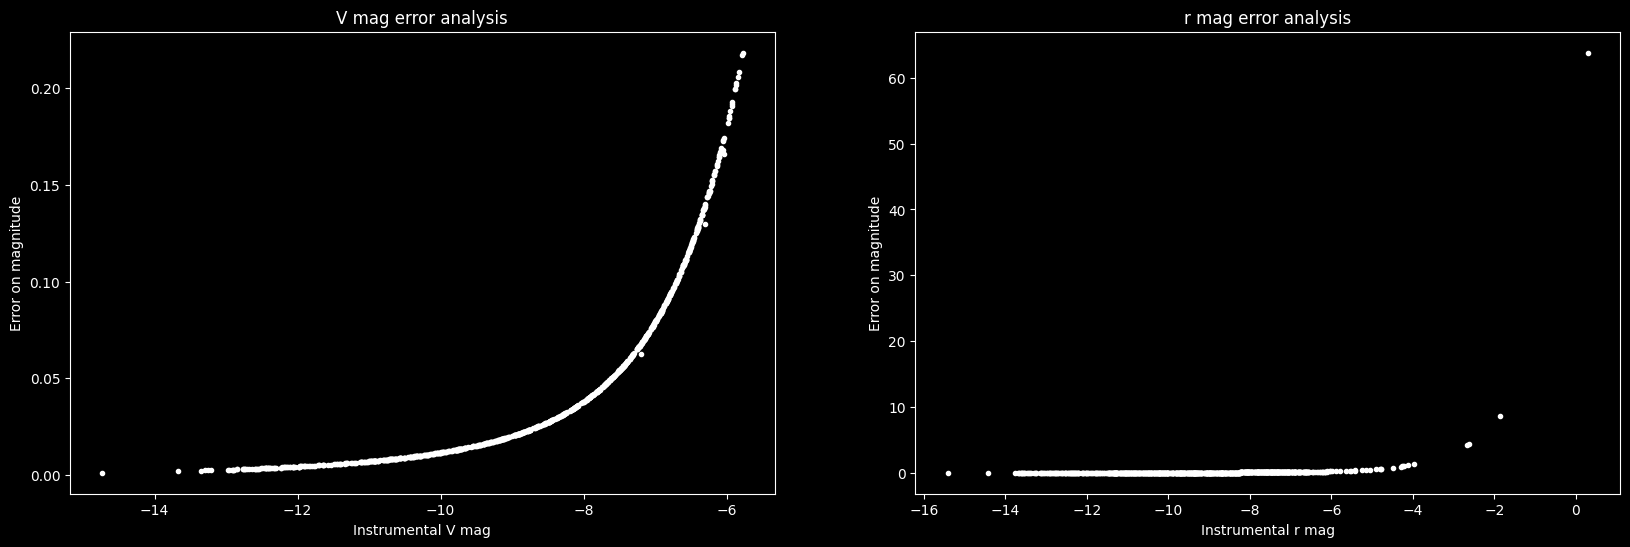

In [39]:
# Carry out aperture photometry
Vflux, Vfluxerr, Vflag = sep.sum_circle(V_data_sub, objects['x'], objects['y'], aper, err=Vbkg.globalrms, gain=1.0)
rflux, rfluxerr, rflag = sep.sum_circle(r_data_sub, objects['x'], objects['y'], aper, err=rbkg.globalrms, gain=1.0)

mask = (Vflux > 0) & (rflux > 0)

Vmag = -2.5 * np.log10(Vflux[mask])
rmag = -2.5 * np.log10(rflux[mask])
Verr = 2.5/math.log(10)*Vfluxerr[mask] / Vflux[mask]
rerr = 2.5/math.log(10)*rfluxerr[mask] / rflux[mask]

plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plt.title("V mag error analysis")
plt.plot(Vmag, Verr, 'w.')
plt.xlabel('Instrumental V mag')
plt.ylabel('Error on magnitude')

plt.subplot(1, 2, 2)
plt.title("r mag error analysis")
plt.plot(rmag, rerr, 'w.')
plt.xlabel('Instrumental r mag')
plt.ylabel('Error on magnitude')

plt.show()


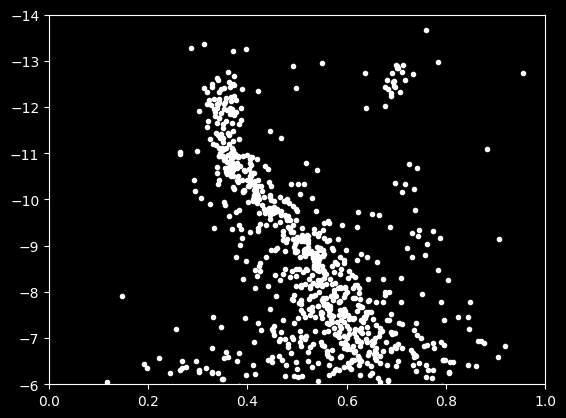

In [40]:
plt.plot(Vmag - rmag, Vmag, 'w.')
plt.ylim(-6, -14)
plt.xlim(0, 1)
plt.show()